In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/Tokyo_Suginami_clean.csv", encoding="utf-8-sig")

use_cols = ["price","area_sqm","station_minutes","building_age"]
df_model = df[use_cols].dropna().copy()

X = df_model[["area_sqm","station_minutes","building_age"]]
y = df_model["price"]

df_model.shape

(2444, 4)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_raw = LinearRegression()
lin_raw.fit(X_train, y_train)

coef_raw = pd.DataFrame({
    "feature": X.columns,
    "coef": lin_raw.coef_
}).sort_values("coef", ascending=False)

coef_raw

,feature,coef
0,area_sqm,1.062604e+06
2,building_age,-7.369058e+05
1,station_minutes,-1.011836e+06


In [3]:
import numpy as np

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

lin_log = LinearRegression()
lin_log.fit(X_train, y_train)

coef_log = pd.DataFrame({
    "feature": X.columns,
    "coef": lin_log.coef_
}).sort_values("coef", ascending=False)

coef_log

,feature,coef
0,area_sqm,0.023215
2,building_age,-0.017388
1,station_minutes,-0.020251


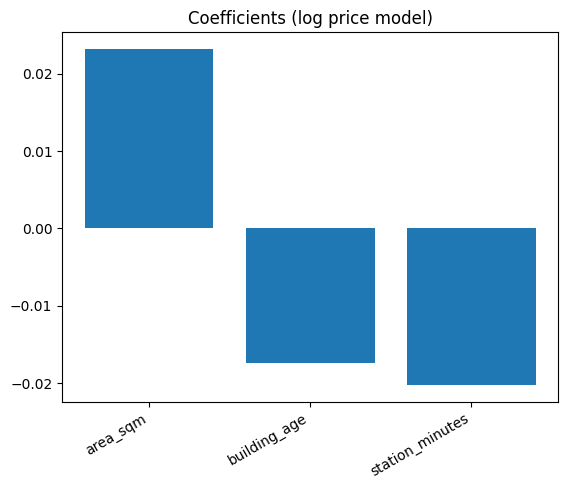

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(coef_log["feature"], coef_log["coef"])
plt.title("Coefficients (log price model)")
plt.xticks(rotation=30, ha="right")
plt.show()

In [5]:
coef_log.assign(
    approx_pct_change_per_1unit = coef_log["coef"] * 100
)

,feature,coef,approx_pct_change_per_1unit
0,area_sqm,0.023215,2.321525
2,building_age,-0.017388,-1.738776
1,station_minutes,-0.020251,-2.025089


In [6]:
import numpy as np

coef_log["pct_change_exact"] = (np.exp(coef_log["coef"]) - 1) * 100
coef_log

,feature,coef,pct_change_exact
0,area_sqm,0.023215,2.348682
2,building_age,-0.017388,-1.723747
1,station_minutes,-0.020251,-2.004722


In [7]:
import numpy as np

effects = {
    "area +10sqm (%)": (np.exp(0.023215*10)-1)*100,
    "age +10years (%)": (np.exp(-0.017388*10)-1)*100,
    "station +5min (%)": (np.exp(-0.020251*5)-1)*100
}

effects

{'area +10sqm (%)': np.float64(26.13089109759601),
 'age +10years (%)': np.float64(-15.960226066346983),
 'station +5min (%)': np.float64(-9.629744065089696)}

Feature impact (log-price model)

本モデルでは log1p(price) を目的変数として線形回帰を行い、係数を価格の相対変化として解釈した。

面積（area_sqm）は正の係数で、面積が大きいほど価格が上昇する傾向が確認できる。

築年数（building_age）と駅徒歩（station_minutes）は負の係数で、築年が古いほど、駅から遠いほど価格が下がる傾向が確認できる。

ただし、これらの係数は「他の変数が同じ」という条件付きの平均的傾向であり、実際の価格差には駅（立地）や用途地域など未投入の要因も大きく影響する。